<h1 style="text-align:center; color:#2E4057;">🏠 Gradient Boosting ile Ev Fiyat Tahmini</h1>
<h3 style="text-align:center; color:#555;">House Prices Regression Dataset</h3>

Bu defterde **Gradient Boosting Regressor** algoritmasını kullanarak ev özelliklerinden (metrekare, oda sayısı, konum kalitesi vb.) satış fiyatını tahmin eden bir **regresyon** modeli kuracağız.

## 📋 Veri Seti Değişken Sözlüğü

| Değişken | Açıklama | Tür |
|---|---|---|
| `Square_Footage` | Evin metrekare (ft²) alanı | Sayısal |
| `Num_Bedrooms` | Yatak odası sayısı | Sayısal |
| `Num_Bathrooms` | Banyo sayısı | Sayısal |
| `Year_Built` | Yapım yılı | Sayısal |
| `Lot_Size` | Arsa büyüklüğü | Sayısal |
| `Garage_Size` | Garaj kapasitesi | Sayısal |
| `Neighborhood_Quality` | Mahalle kalite puanı (1-10) | Sayısal |
| `House_Price` | Hedef değişken — satış fiyatı ($) | Sayısal |

## 1️⃣ Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2️⃣ Veri Setinin Yüklenmesi ve Keşfi

In [2]:
df = pd.read_csv('house/house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")

📐 Boyut : 1,000 satır × 8 sütun


In [4]:
print("❓ Eksik Değer Analizi:")
print(df.isnull().sum().sum())

❓ Eksik Değer Analizi:
0


In [5]:
print("📊 İstatistiksel Özet:")
df.describe().T

📊 İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


## 3️⃣ Görsel Keşifsel Veri Analizi (EDA)

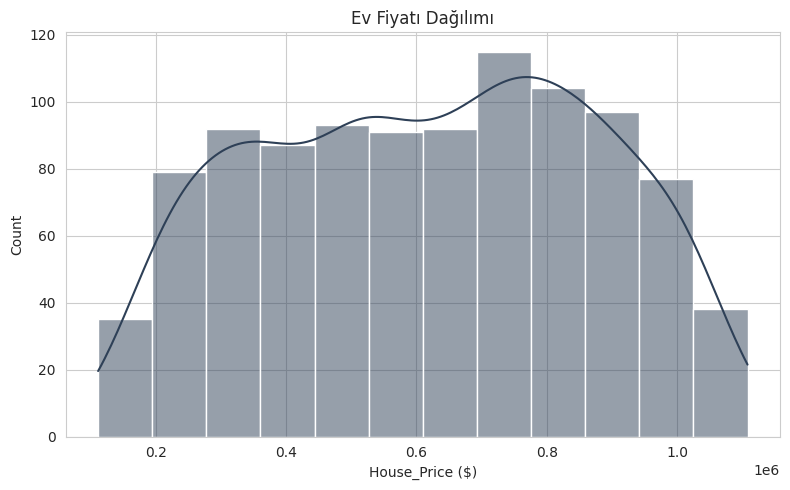

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['House_Price'], kde=True, color='#2E4057')
plt.title('Ev Fiyatı Dağılımı')
plt.xlabel('House_Price ($)')
plt.tight_layout()
plt.show()

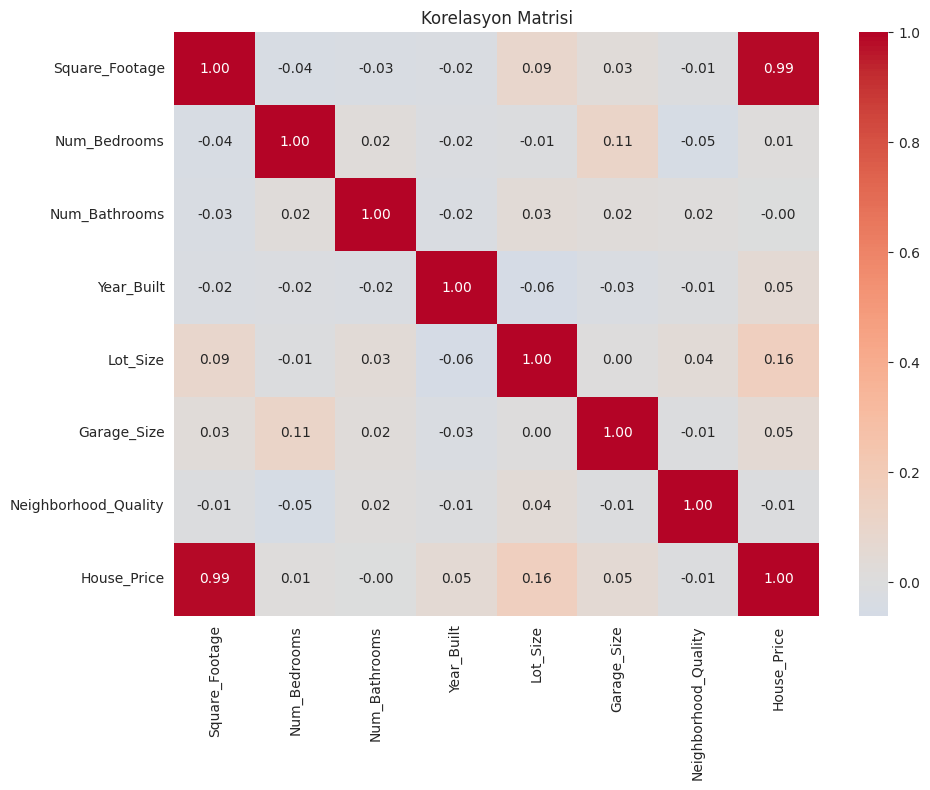

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

/tmp/ipykernel_675/788697061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood_Quality', y='House_Price', data=df, ax=axes[1], palette='viridis')


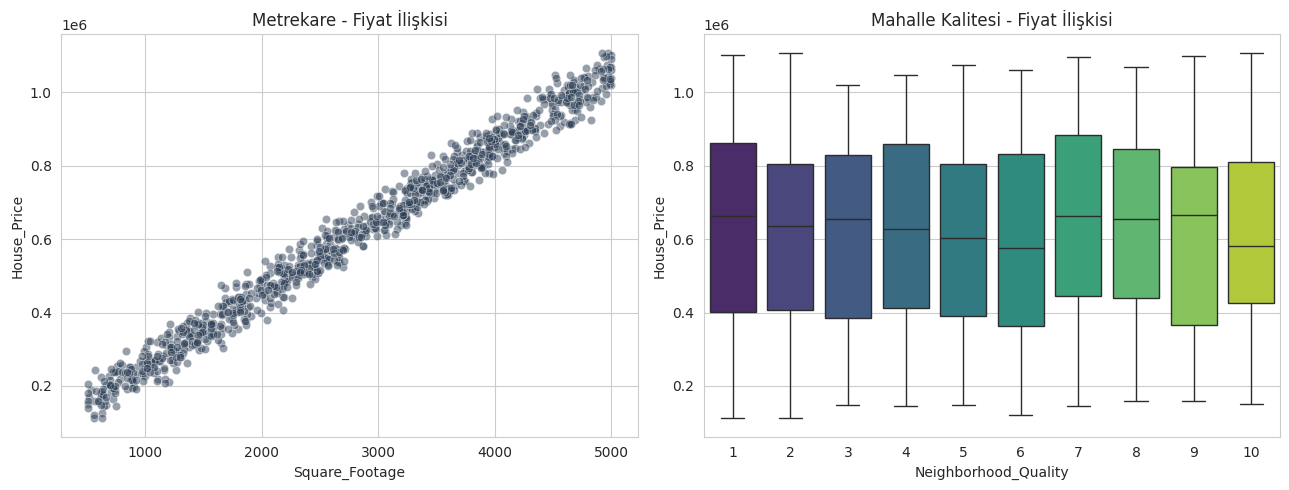

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x='Square_Footage', y='House_Price', data=df, ax=axes[0], color='#2E4057', alpha=0.5)
axes[0].set_title('Metrekare - Fiyat İlişkisi')

sns.boxplot(x='Neighborhood_Quality', y='House_Price', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Mahalle Kalitesi - Fiyat İlişkisi')
plt.tight_layout()
plt.show()

## 4️⃣ Veri Ön İşleme

In [9]:
df_clean = df.copy()

X = df_clean.drop(columns=['House_Price'])
y = df_clean['House_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

Eğitim seti: (800, 7), Test seti: (200, 7)


## 5️⃣ Gradient Boosting Regresyon – Fiyat Tahmini

In [10]:
gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb_reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [11]:
y_pred = gb_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 11,805.86
RMSE : 14,579.72
R²   : 0.9967


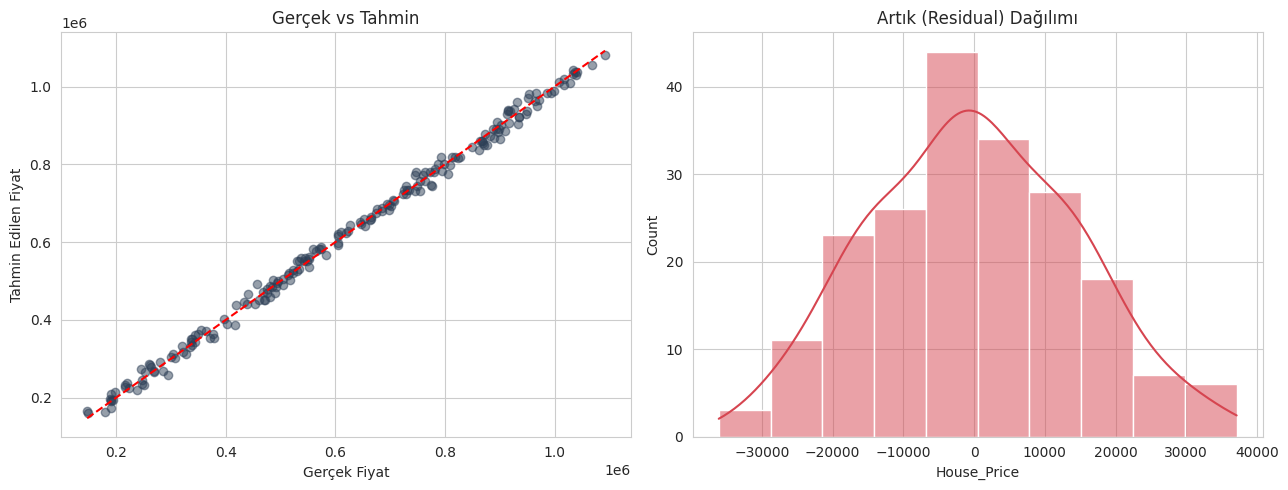

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#2E4057')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Gerçek Fiyat')
axes[0].set_ylabel('Tahmin Edilen Fiyat')
axes[0].set_title('Gerçek vs Tahmin')

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='#D64550')
axes[1].set_title('Artık (Residual) Dağılımı')
plt.tight_layout()
plt.show()

## 6️⃣ Eğitim Kaybının İterasyonlar Boyunca Azalması

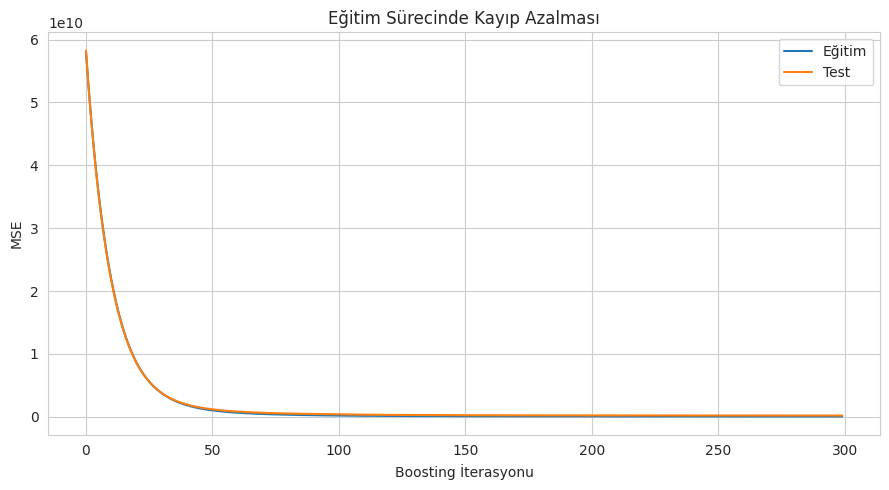

In [13]:
train_deviance = gb_reg.train_score_
test_deviance = [mean_squared_error(y_test, y_pred_i) for y_pred_i in gb_reg.staged_predict(X_test)]

plt.figure(figsize=(9, 5))
plt.plot(train_deviance, label='Eğitim')
plt.plot(test_deviance, label='Test')
plt.xlabel('Boosting İterasyonu')
plt.ylabel('MSE')
plt.title('Eğitim Sürecinde Kayıp Azalması')
plt.legend()
plt.tight_layout()
plt.show()

## 7️⃣ Özellik Önemi (Feature Importance)

/tmp/ipykernel_675/4079561787.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


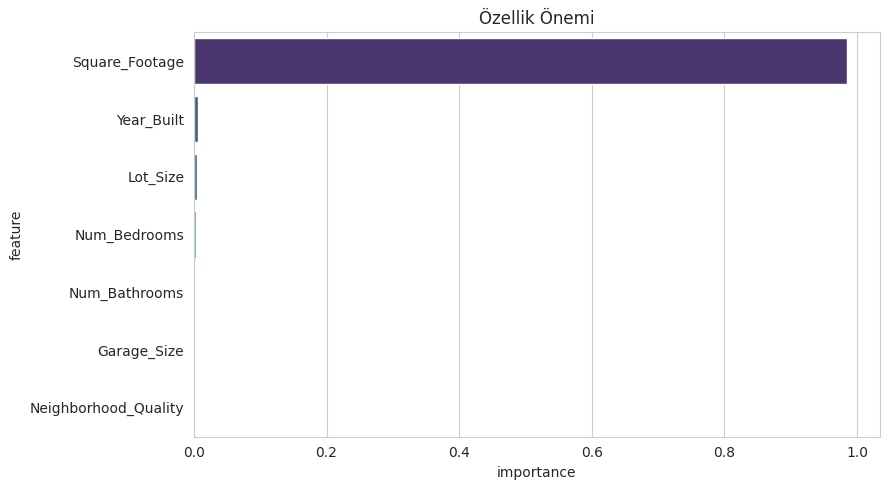

In [14]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_reg.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('Özellik Önemi')
plt.tight_layout()
plt.show()

## 8️⃣ Hiperparametre Optimizasyonu (Grid Search CV)

In [15]:
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi CV R²        : {grid_search.best_score_:.4f}")

En iyi parametreler: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
En iyi CV R²        : 0.9963


In [16]:
best_gb = grid_search.best_estimator_
y_pred_best = best_gb.predict(X_test)

print(f"Optimize Model R²   : {r2_score(y_test, y_pred_best):.4f}")
print(f"Optimize Model RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.2f}")

Optimize Model R²   : 0.9970
Optimize Model RMSE : 13,940.07


## 9️⃣ Çapraz Doğrulama (5-Fold Cross Validation)

In [17]:
cv_scores = cross_val_score(best_gb, X, y, cv=5, scoring='r2')
print(f"5-Fold CV R² skorları: {np.round(cv_scores, 4)}")
print(f"Ortalama: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-Fold CV R² skorları: [0.997  0.9969 0.9969 0.9969 0.9961]
Ortalama: 0.9968  |  Std: 0.0003


## 🔟 Sonuç ve Değerlendirme

### 📈 Gradient Boosting Regresyon Modeli — Ev Fiyatı Tahmini

- `Square_Footage` (metrekare) ve `Neighborhood_Quality` (mahalle kalitesi) fiyatı en çok açıklayan değişkenler olarak öne çıkmaktadır.
- Eğitim/test kaybı grafiğinde iterasyon sayısı arttıkça hatanın azaldığı, ancak belirli bir noktadan sonra test hatasının platoya ulaştığı gözlemlenmiştir — bu, `n_estimators` için makul bir üst sınır seçmenin önemini göstermektedir.
- Grid Search ile optimize edilen model, düşük `learning_rate` ve orta düzey `max_depth` kombinasyonlarında en iyi genelleme performansını vermiştir.
- 5-Fold çapraz doğrulama sonuçları, modelin farklı veri bölmelerinde tutarlı bir R² skoru ürettiğini göstermektedir.
- **Geliştirme Önerileri:** Erken durdurma (early stopping), özellik ölçekleme ve ek türetilmiş özellikler (örn. oda başına metrekare) ile model performansı artırılabilir.